# MODUL 10 - CLUSTERING
## K-Modes Clustering pada Data Kartu Kredit (CC_GENERAL)
### Kelompok Ganjil

**K-Modes** adalah algoritma clustering yang dirancang khusus untuk data **kategorik**. Berbeda dengan K-Means yang menggunakan rata-rata (mean) dan jarak Euclidean, K-Modes menggunakan **modus** (nilai terbanyak) sebagai centroid dan **Hamming distance** (jumlah perbedaan atribut) sebagai ukuran kemiripan antar data.

**Langkah-langkah K-Modes:**
1. Inisialisasi centroid awal (mode) secara random
2. Assign setiap data ke cluster dengan mode terdekat (Hamming distance terkecil)
3. Perbarui mode untuk setiap cluster
4. Iterasi sampai konvergen

## 1. Import Library

In [28]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from kmodes.kmodes import KModes
from sklearn.metrics import silhouette_score
import warnings
warnings.filterwarnings('ignore')

print('Semua library berhasil diimport!')

Semua library berhasil diimport!


## 2. Import dan Eksplorasi Data

In [29]:
# Import data
df = pd.read_csv('CC GENERAL.csv')
df.head()

,CUST_ID,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,C10001,40.900749,0.818182,95.40,0.00,95.4,0.000000,0.166667,0.000000,0.083333,0.000000,0,2,1000.0,201.802084,139.509787,0.000000,12
1,C10002,3202.467416,0.909091,0.00,0.00,0.0,6442.945483,0.000000,0.000000,0.000000,0.250000,4,0,7000.0,4103.032597,1072.340217,0.222222,12
2,C10003,2495.148862,1.000000,773.17,773.17,0.0,0.000000,1.000000,1.000000,0.000000,0.000000,0,12,7500.0,622.066742,627.284787,0.000000,12
3,C10004,1666.670542,0.636364,1499.00,1499.00,0.0,205.788017,0.083333,0.083333,0.000000,0.083333,1,1,7500.0,0.000000,NaN,0.000000,12
4,C10005,817.714335,1.000000,16.00,16.00,0.0,0.000000,0.083333,0.083333,0.000000,0.000000,0,1,1200.0,678.334763,244.791237,0.000000,12


In [30]:
# Amati bentuk data
print('Shape data:', df.shape)
print(f'Jumlah baris: {df.shape[0]}, Jumlah kolom: {df.shape[1]}')

Shape data: (8950, 18)
Jumlah baris: 8950, Jumlah kolom: 18


In [31]:
# Melihat ringkasan statistik deskriptif
df.describe()

,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
count,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8949.000000,8950.000000,8637.000000,8950.000000,8950.000000
mean,1564.474828,0.877271,1003.204834,592.437371,411.067645,978.871112,0.490351,0.202458,0.364437,0.135144,3.248827,14.709832,4494.449450,1733.143852,864.206542,0.153715,11.517318
std,2081.531879,0.236904,2136.634782,1659.887917,904.338115,2097.163877,0.401371,0.298336,0.397448,0.200121,6.824647,24.857649,3638.815725,2895.063757,2372.446607,0.292499,1.338331
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,50.000000,0.000000,0.019163,0.000000,6.000000
25%,128.281915,0.888889,39.635000,0.000000,0.000000,0.000000,0.083333,0.000000,0.000000,0.000000,0.000000,1.000000,1600.000000,383.276166,169.123707,0.000000,12.000000
50%,873.385231,1.000000,361.280000,38.000000,89.000000,0.000000,0.500000,0.083333,0.166667,0.000000,0.000000,7.000000,3000.000000,856.901546,312.343947,0.000000,12.000000
75%,2054.140036,1.000000,1110.130000,577.405000,468.637500,1113.821139,0.916667,0.300000,0.750000,0.222222,4.000000,17.000000,6500.000000,1901.134317,825.485459,0.142857,12.000000
max,19043.138560,1.000000,49039.570000,40761.250000,22500.000000,47137.211760,1.000000,1.000000,1.000000,1.500000,123.000000,358.000000,30000.000000,50721.483360,76406.207520,1.000000,12.000000


In [32]:
# Cek tipe data
df.dtypes

CUST_ID                                 str
BALANCE                             float64
BALANCE_FREQUENCY                   float64
PURCHASES                           float64
ONEOFF_PURCHASES                    float64
INSTALLMENTS_PURCHASES              float64
CASH_ADVANCE                        float64
PURCHASES_FREQUENCY                 float64
ONEOFF_PURCHASES_FREQUENCY          float64
PURCHASES_INSTALLMENTS_FREQUENCY    float64
CASH_ADVANCE_FREQUENCY              float64
CASH_ADVANCE_TRX                      int64
PURCHASES_TRX                         int64
CREDIT_LIMIT                        float64
PAYMENTS                            float64
MINIMUM_PAYMENTS                    float64
PRC_FULL_PAYMENT                    float64
TENURE                                int64
dtype: object

In [33]:
# Cek null data
print('Jumlah nilai null per kolom:')
print(df.isnull().sum())
print(f'\nTotal nilai null: {df.isnull().sum().sum()}')

Jumlah nilai null per kolom:
CUST_ID                               0
BALANCE                               0
BALANCE_FREQUENCY                     0
PURCHASES                             0
ONEOFF_PURCHASES                      0
INSTALLMENTS_PURCHASES                0
CASH_ADVANCE                          0
PURCHASES_FREQUENCY                   0
ONEOFF_PURCHASES_FREQUENCY            0
PURCHASES_INSTALLMENTS_FREQUENCY      0
CASH_ADVANCE_FREQUENCY                0
CASH_ADVANCE_TRX                      0
PURCHASES_TRX                         0
CREDIT_LIMIT                          1
PAYMENTS                              0
MINIMUM_PAYMENTS                    313
PRC_FULL_PAYMENT                      0
TENURE                                0
dtype: int64

Total nilai null: 314


## 3. Preprocessing Data untuk K-Modes

K-Modes bekerja pada data **kategorik**. Karena dataset CC_GENERAL berisi data numerik, kita perlu melakukan **diskretisasi** (binning) untuk mengubah kolom numerik menjadi kategori yang bermakna.

In [34]:
# Tangani missing values terlebih dahulu
df_clean = df.copy()

# Isi CREDIT_LIMIT dan MINIMUM_PAYMENTS yang null dengan median
df_clean['CREDIT_LIMIT'].fillna(df_clean['CREDIT_LIMIT'].median(), inplace=True)
df_clean['MINIMUM_PAYMENTS'].fillna(df_clean['MINIMUM_PAYMENTS'].median(), inplace=True)

print('Cek null setelah handling:')
print(df_clean.isnull().sum()[df_clean.isnull().sum() > 0])
print('Tidak ada lagi nilai null.' if df_clean.isnull().sum().sum() == 0 else 'Masih ada nilai null.')

Cek null setelah handling:
CREDIT_LIMIT          1
MINIMUM_PAYMENTS    313
dtype: int64
Masih ada nilai null.


In [35]:
# Pilih fitur yang relevan untuk clustering
features = ['BALANCE', 'PURCHASES', 'CASH_ADVANCE', 'CREDIT_LIMIT', 
            'PAYMENTS', 'MINIMUM_PAYMENTS', 'PRC_FULL_PAYMENT', 'TENURE']

df_selected = df_clean[features].copy()
print('Fitur yang dipilih:', features)

Fitur yang dipilih: ['BALANCE', 'PURCHASES', 'CASH_ADVANCE', 'CREDIT_LIMIT', 'PAYMENTS', 'MINIMUM_PAYMENTS', 'PRC_FULL_PAYMENT', 'TENURE']


In [36]:
# Diskretisasi: ubah fitur numerik menjadi kategori dengan qcut (kuantil-based)
df_cat = pd.DataFrame()

bin_labels = ['Rendah', 'Sedang', 'Tinggi']

for col in features:
    binned = pd.qcut(df_selected[col], q=3, labels=False, duplicates='drop')
    n_bins = len(binned.unique())
    labels = bin_labels[:n_bins]
    df_cat[col] = pd.qcut(df_selected[col], q=3, labels=labels, duplicates='drop')

# Ubah ke tipe object (string) agar kompatibel dengan K-Modes
df_cat = df_cat.astype(str)

print('Data setelah diskretisasi:')
df_cat.head(10)

Data setelah diskretisasi:


,BALANCE,PURCHASES,CASH_ADVANCE,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,Rendah,Rendah,Rendah,Rendah,Rendah,Rendah,Rendah,Rendah
1,Tinggi,Rendah,Sedang,Tinggi,Tinggi,Tinggi,Sedang,Rendah
2,Tinggi,Tinggi,Rendah,Tinggi,Sedang,Tinggi,Rendah,Rendah
3,Tinggi,Tinggi,Rendah,Tinggi,Rendah,NaN,Rendah,Rendah
4,Sedang,Rendah,Rendah,Rendah,Sedang,Sedang,Rendah,Rendah
5,Tinggi,Tinggi,Rendah,Rendah,Sedang,Tinggi,Rendah,Rendah
6,Sedang,Tinggi,Rendah,Tinggi,Tinggi,Sedang,Sedang,Rendah
7,Tinggi,Sedang,Rendah,Sedang,Sedang,Sedang,Rendah,Rendah
8,Sedang,Tinggi,Rendah,Tinggi,Sedang,Sedang,Rendah,Rendah
9,Rendah,Tinggi,Rendah,Tinggi,Sedang,Rendah,Rendah,Rendah


In [37]:
# Cek distribusi kategori pada salah satu fitur
print('Distribusi kategori BALANCE:')
print(df_cat['BALANCE'].value_counts())
print()
print('Distribusi kategori CREDIT_LIMIT:')
print(df_cat['CREDIT_LIMIT'].value_counts())

Distribusi kategori BALANCE:
BALANCE
Rendah    2984
Tinggi    2983
Sedang    2983
Name: count, dtype: int64

Distribusi kategori CREDIT_LIMIT:
CREDIT_LIMIT
Sedang    3061
Rendah    2990
Tinggi    2898
Name: count, dtype: int64


## 4. Visualisasi Data

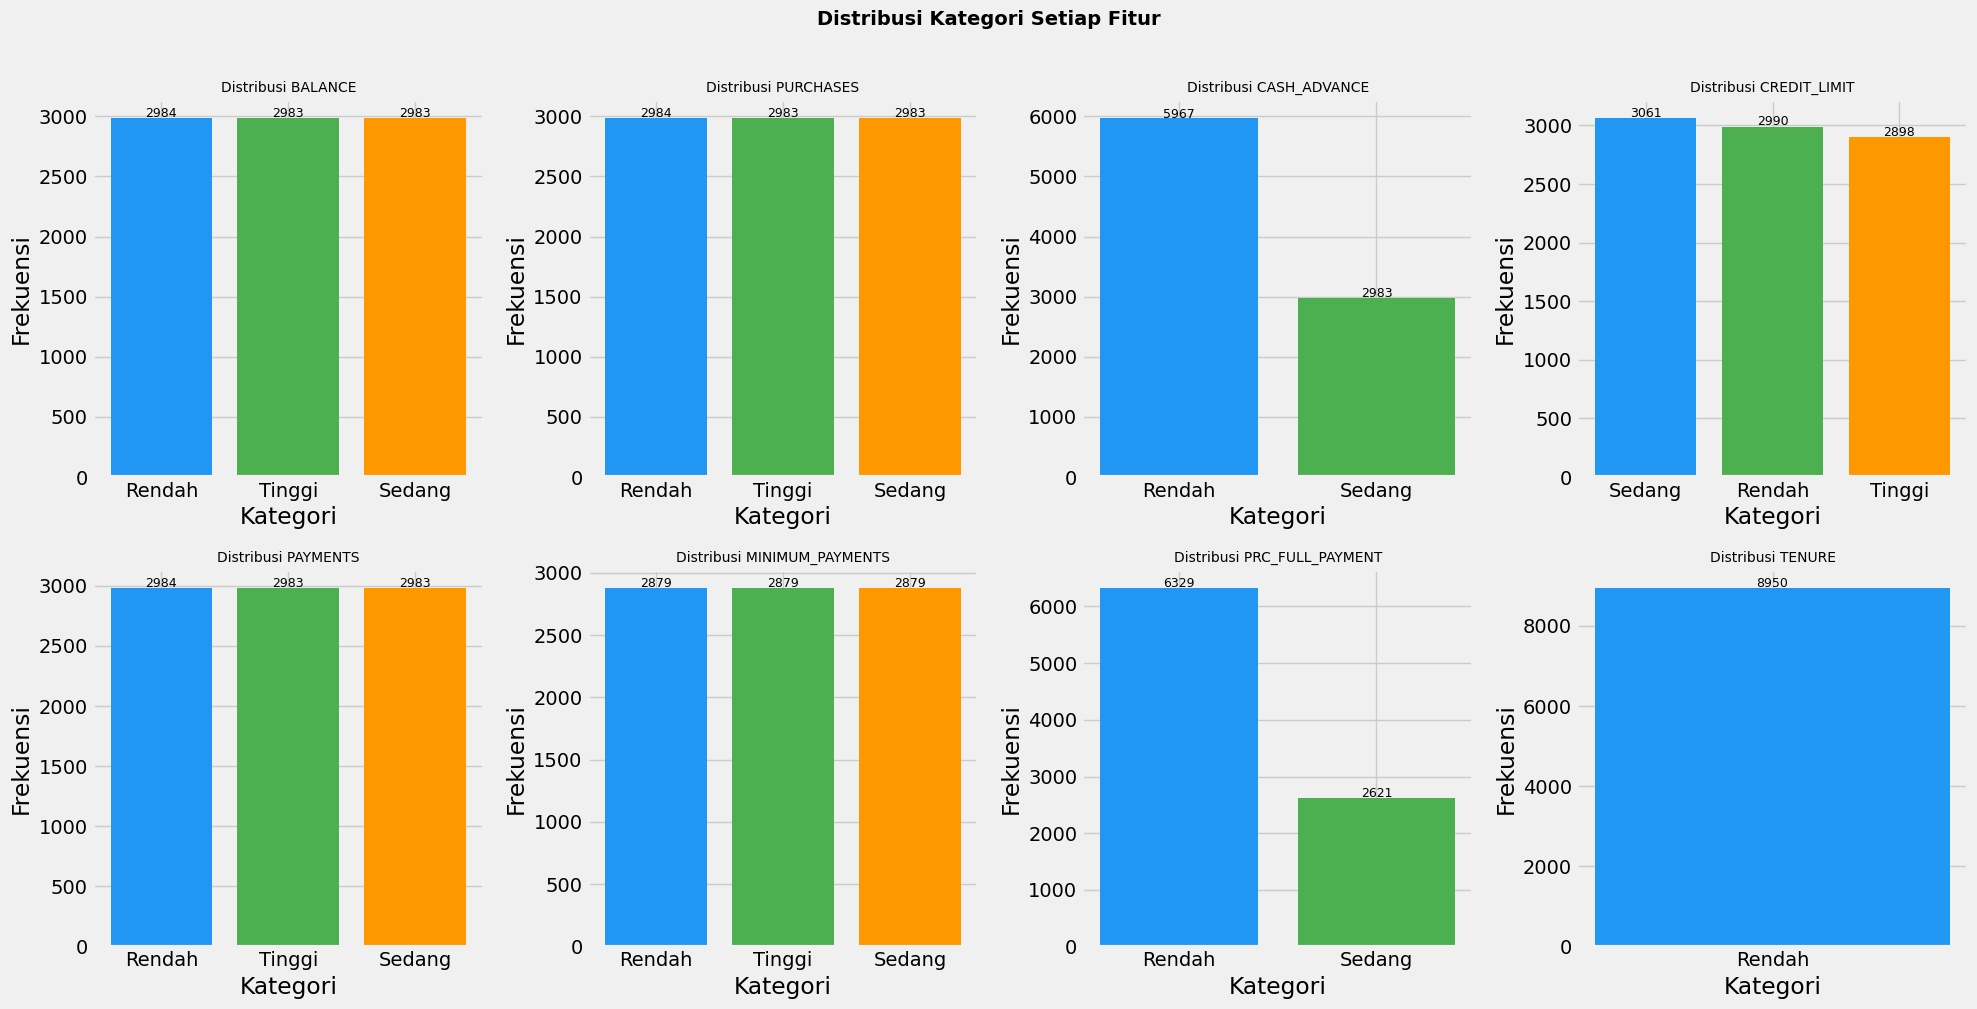

In [38]:
# Visualisasi distribusi kategori semua fitur
plt.style.use('fivethirtyeight')
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()

colors = ['#2196F3', '#4CAF50', '#FF9800']

for i, col in enumerate(features):
    counts = df_cat[col].value_counts()
    axes[i].bar(counts.index, counts.values, color=colors[:len(counts)])
    axes[i].set_title(f'Distribusi {col}', fontsize=10)
    axes[i].set_xlabel('Kategori')
    axes[i].set_ylabel('Frekuensi')
    for j, v in enumerate(counts.values):
        axes[i].text(j, v + 10, str(v), ha='center', fontsize=9)

plt.suptitle('Distribusi Kategori Setiap Fitur', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

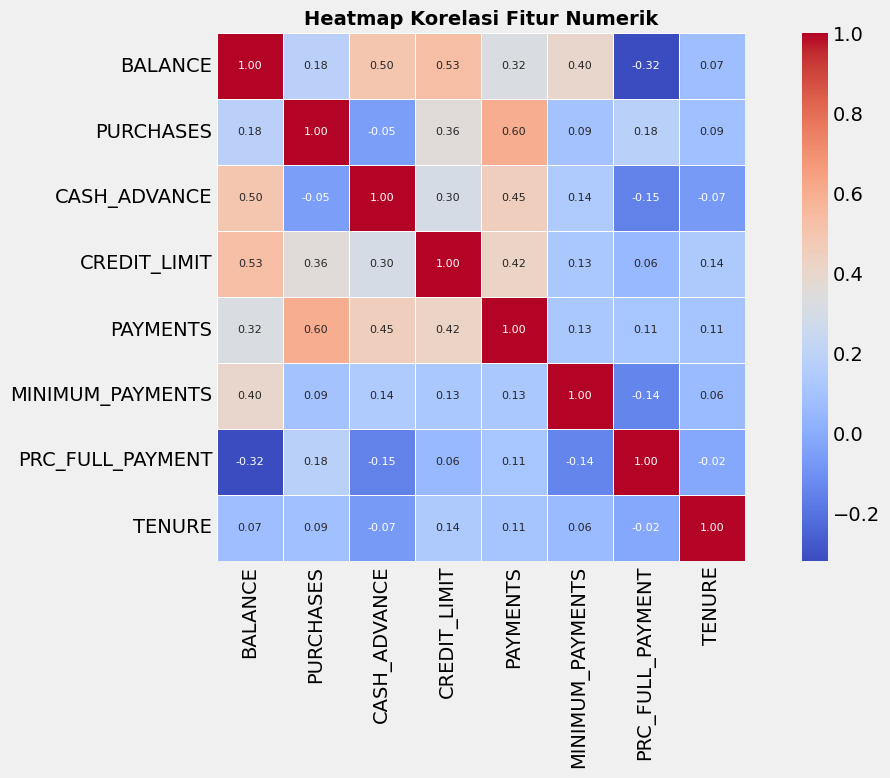

In [39]:
# Visualisasi heatmap korelasi antar fitur numerik asli
plt.figure(figsize=(12, 8))
corr = df_selected.corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', 
            square=True, linewidths=0.5, annot_kws={'size': 8})
plt.title('Heatmap Korelasi Fitur Numerik', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 5. Menentukan Jumlah Cluster Optimal (Elbow Method)

Pada K-Modes, metrik yang digunakan untuk Elbow Method adalah **total cost** (total jumlah perbedaan/dissimilaritas), bukan inertia seperti pada K-Means.

In [40]:
# Elbow Method untuk K-Modes
# Handle NaN values in df_cat before K-Modes
df_cat_clean = df_cat.fillna(df_cat.mode().iloc[0])

# Elbow Method untuk K-Modes
cost_list = []
K_range = range(1, 11)

print('Menghitung cost untuk setiap nilai K...')
for k in K_range:
    km = KModes(n_clusters=k, init='Huang', n_init=5, verbose=0, random_state=42)
    km.fit(df_cat_clean)
    cost_list.append(km.cost_)
    print(f'  K={k}, Cost={km.cost_:.2f}')

print('\nSelesai!')

Menghitung cost untuk setiap nilai K...
  K=1, Cost=35148.00
  K=2, Cost=24490.00
  K=3, Cost=20024.00
  K=4, Cost=18771.00
  K=5, Cost=16632.00
  K=6, Cost=16018.00
  K=7, Cost=14179.00
  K=8, Cost=14350.00
  K=9, Cost=13045.00
  K=10, Cost=12180.00

Selesai!


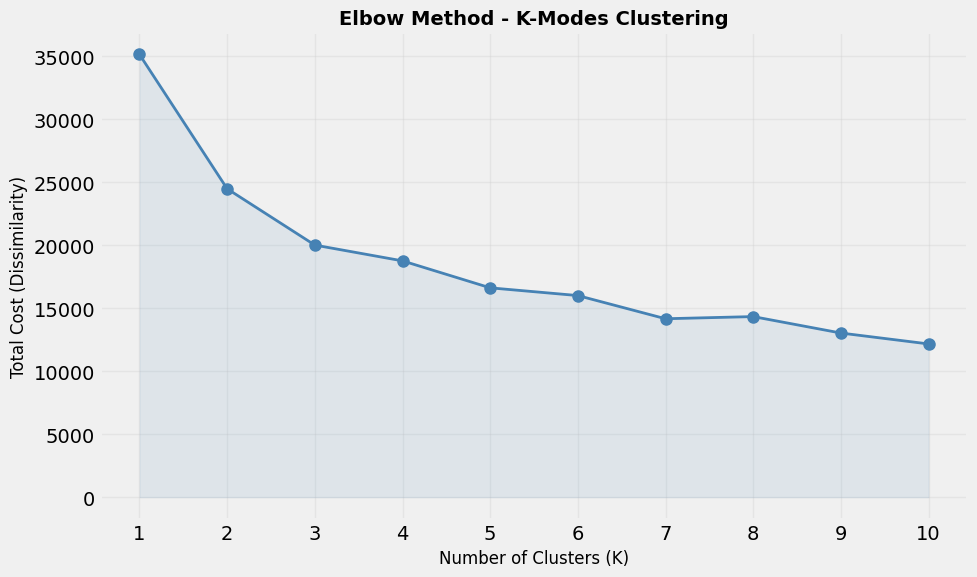


Amati grafik di atas. Pilih nilai K di titik "siku" (elbow) di mana penurunan cost mulai melambat.


In [41]:
# Plot Elbow Method
plt.style.use('fivethirtyeight')
plt.figure(figsize=(10, 6))
plt.plot(K_range, cost_list, 'o-', color='steelblue', linewidth=2, markersize=8)
plt.fill_between(K_range, cost_list, alpha=0.1, color='steelblue')
plt.xlabel('Number of Clusters (K)', fontsize=12)
plt.ylabel('Total Cost (Dissimilarity)', fontsize=12)
plt.title('Elbow Method - K-Modes Clustering', fontsize=14, fontweight='bold')
plt.xticks(K_range)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print('\nAmati grafik di atas. Pilih nilai K di titik "siku" (elbow) di mana penurunan cost mulai melambat.')

## 6. Membangun Model K-Modes

Berdasarkan Elbow Method di atas, kita memilih **K = 3** (titik elbow).

In [43]:
# Membangun K-Modes dengan K optimal
optimal_k = 3  # Sesuaikan berdasarkan hasil Elbow Method

km_model = KModes(
    n_clusters=optimal_k,
    init='Huang',       # Metode inisialisasi: 'Huang' atau 'Cao'
    n_init=10,          # Jumlah inisialisasi
    verbose=0,
    random_state=42
)

cluster_labels = km_model.fit_predict(df_cat_clean)

print(f'K-Modes berhasil dibangun dengan K = {optimal_k}')
print(f'Total Cost (Dissimilarity): {km_model.cost_:.4f}')
print(f'Jumlah iterasi sampai konvergen: {km_model.n_iter_}')

K-Modes berhasil dibangun dengan K = 3
Total Cost (Dissimilarity): 20004.0000
Jumlah iterasi sampai konvergen: 2


In [44]:
# Melihat Cluster Centroids (Mode)
centroids_df = pd.DataFrame(km_model.cluster_centroids_, columns=features)
centroids_df.index = [f'Cluster {i}' for i in range(optimal_k)]

print('Cluster Centroids (Mode tiap cluster):')
centroids_df

Cluster Centroids (Mode tiap cluster):


,BALANCE,PURCHASES,CASH_ADVANCE,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
Cluster 0,Sedang,Rendah,Rendah,Rendah,Rendah,Sedang,Rendah,Rendah
Cluster 1,Rendah,Sedang,Rendah,Sedang,Sedang,Rendah,Sedang,Rendah
Cluster 2,Tinggi,Tinggi,Sedang,Tinggi,Tinggi,Tinggi,Rendah,Rendah


In [45]:
# Tambahkan label cluster ke dataset asli
df_result = df_clean.copy()
df_result['Cluster'] = cluster_labels

# Distribusi jumlah anggota tiap cluster
cluster_dist = df_result['Cluster'].value_counts().sort_index()
print('Distribusi anggota per cluster:')
for cluster, count in cluster_dist.items():
    pct = count / len(df_result) * 100
    print(f'  Cluster {cluster}: {count} pelanggan ({pct:.1f}%)')

Distribusi anggota per cluster:
  Cluster 0: 3928 pelanggan (43.9%)
  Cluster 1: 2497 pelanggan (27.9%)
  Cluster 2: 2525 pelanggan (28.2%)


## 7. Evaluasi Model - Silhouette Score

In [46]:
# Hitung Silhouette Score menggunakan data numerik asli
# (Silhouette Score membutuhkan data numerik untuk menghitung jarak)
from sklearn.preprocessing import LabelEncoder

# Encode data kategorik ke numerik untuk perhitungan silhouette
df_encoded = df_cat.copy()
le = LabelEncoder()
for col in df_encoded.columns:
    df_encoded[col] = le.fit_transform(df_encoded[col])

# Hitung silhouette score
sil_score = silhouette_score(df_encoded, cluster_labels, metric='hamming')
print(f'Silhouette Score (Hamming): {sil_score:.4f}')
print()
print('Interpretasi Silhouette Score:')
print('  0.71 - 1.00 : Struktur cluster sangat kuat')
print('  0.51 - 0.70 : Struktur cluster cukup kuat')
print('  0.26 - 0.50 : Struktur cluster lemah (mungkin perlu K berbeda)')
print('  < 0.25      : Tidak ada struktur cluster yang signifikan')
if sil_score >= 0.51:
    print(f'\n→ Nilai {sil_score:.4f} menunjukkan struktur cluster yang cukup/sangat kuat.')
elif sil_score >= 0.26:
    print(f'\n→ Nilai {sil_score:.4f} menunjukkan struktur cluster yang lemah. Pertimbangkan nilai K lain.')
else:
    print(f'\n→ Nilai {sil_score:.4f} menunjukkan cluster kurang signifikan.')

Silhouette Score (Hamming): 0.2774

Interpretasi Silhouette Score:
  0.71 - 1.00 : Struktur cluster sangat kuat
  0.51 - 0.70 : Struktur cluster cukup kuat
  0.26 - 0.50 : Struktur cluster lemah (mungkin perlu K berbeda)
  < 0.25      : Tidak ada struktur cluster yang signifikan

→ Nilai 0.2774 menunjukkan struktur cluster yang lemah. Pertimbangkan nilai K lain.


## 8. Visualisasi Hasil Clustering

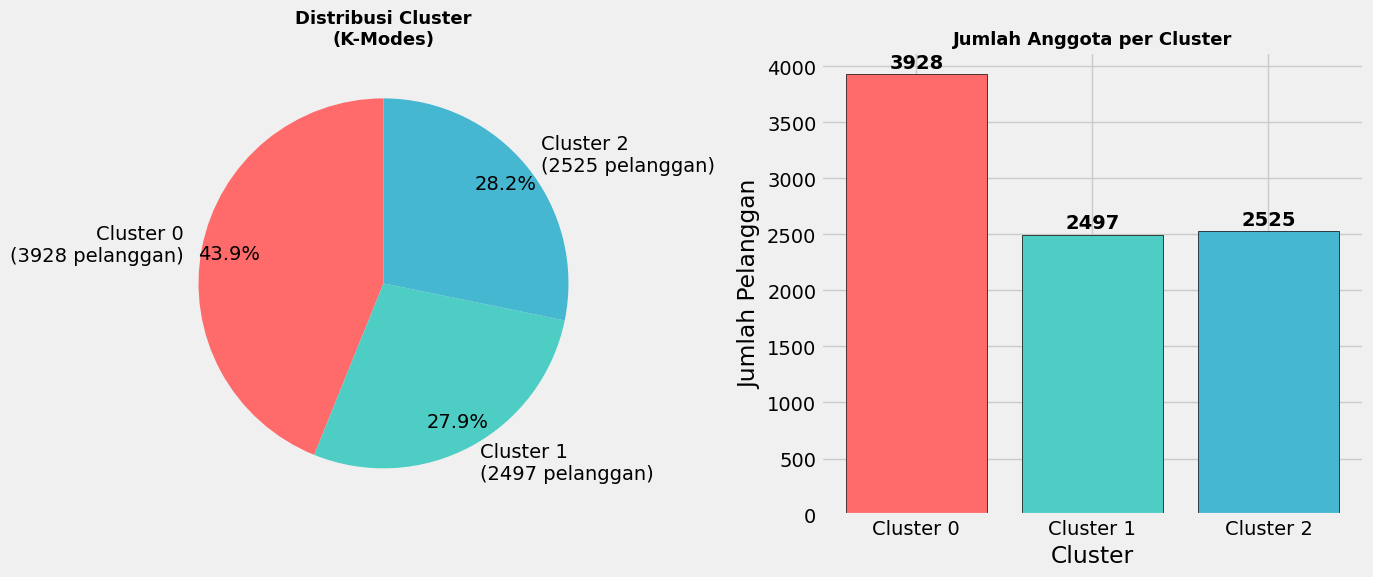

In [47]:
# Visualisasi distribusi cluster (pie chart)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Pie chart
colors_pie = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4', '#FFEAA7']
cluster_counts = df_result['Cluster'].value_counts().sort_index()
labels_pie = [f'Cluster {i}\n({v} pelanggan)' for i, v in cluster_counts.items()]

ax1.pie(cluster_counts.values, labels=labels_pie, 
        colors=colors_pie[:optimal_k], autopct='%1.1f%%',
        startangle=90, pctdistance=0.85)
ax1.set_title('Distribusi Cluster\n(K-Modes)', fontsize=13, fontweight='bold')

# Bar chart
bars = ax2.bar([f'Cluster {i}' for i in cluster_counts.index], 
               cluster_counts.values,
               color=colors_pie[:optimal_k], edgecolor='black', linewidth=0.5)
for bar, val in zip(bars, cluster_counts.values):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 20,
             str(val), ha='center', va='bottom', fontweight='bold')
ax2.set_title('Jumlah Anggota per Cluster', fontsize=13, fontweight='bold')
ax2.set_xlabel('Cluster')
ax2.set_ylabel('Jumlah Pelanggan')

plt.tight_layout()
plt.show()

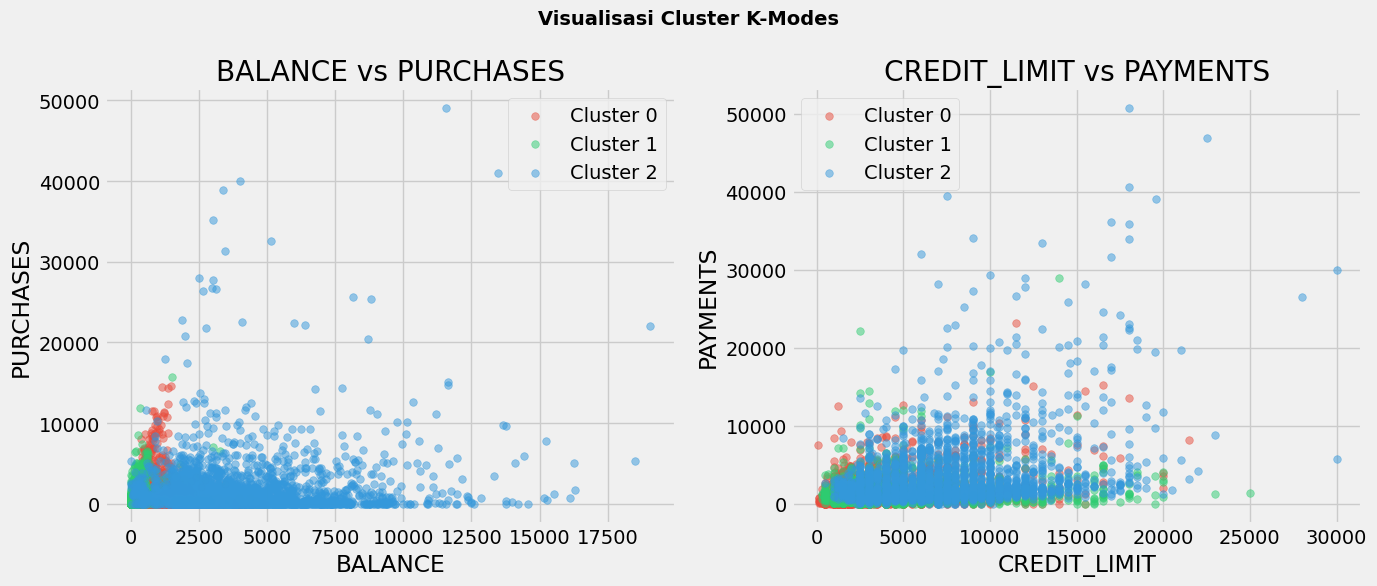

In [48]:
# Visualisasi scatter plot: BALANCE vs PURCHASES berdasarkan cluster
plt.style.use('fivethirtyeight')
plt.figure(figsize=(14, 6))

scatter_pairs = [
    ('BALANCE', 'PURCHASES'),
    ('CREDIT_LIMIT', 'PAYMENTS')
]

colors_scatter = ['#E74C3C', '#2ECC71', '#3498DB', '#F39C12']

for idx, (x_col, y_col) in enumerate(scatter_pairs, 1):
    plt.subplot(1, 2, idx)
    for cluster_id in range(optimal_k):
        mask = df_result['Cluster'] == cluster_id
        plt.scatter(
            df_result.loc[mask, x_col],
            df_result.loc[mask, y_col],
            c=colors_scatter[cluster_id],
            label=f'Cluster {cluster_id}',
            alpha=0.5, s=30
        )
    plt.xlabel(x_col)
    plt.ylabel(y_col)
    plt.title(f'{x_col} vs {y_col}')
    plt.legend()

plt.suptitle('Visualisasi Cluster K-Modes', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

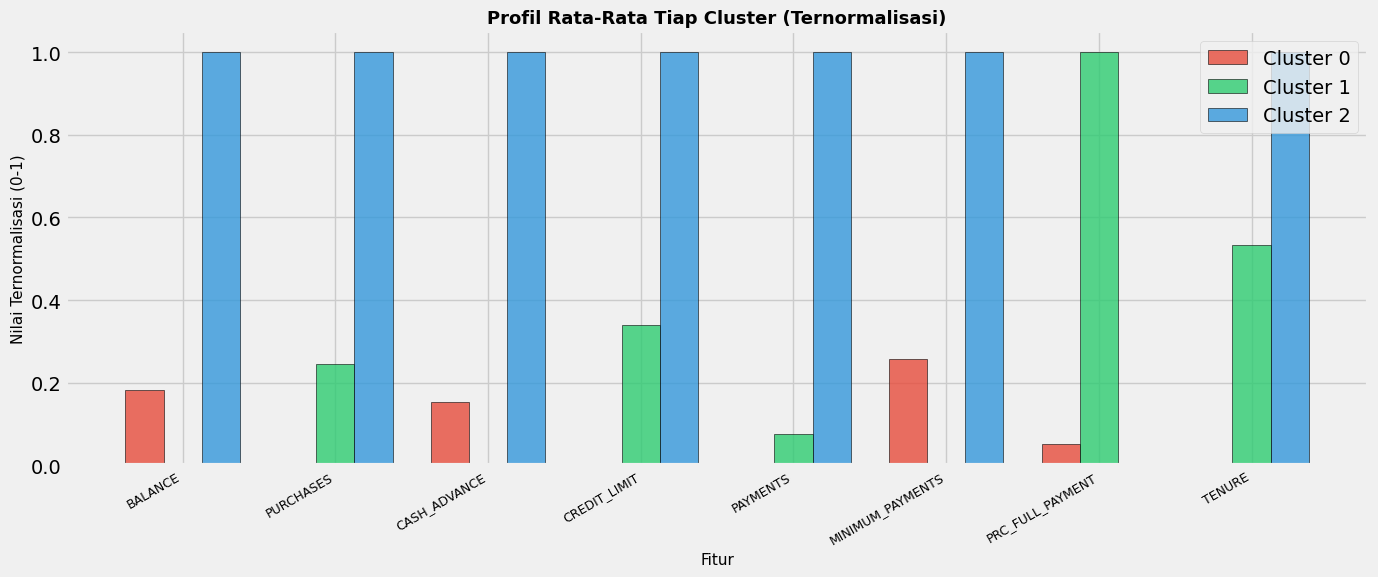

In [49]:
# Visualisasi profil tiap cluster (rata-rata fitur numerik)
cluster_profile = df_result.groupby('Cluster')[features].mean()

# Normalisasi untuk radar/bar chart
cluster_profile_norm = (cluster_profile - cluster_profile.min()) / \
                       (cluster_profile.max() - cluster_profile.min())

fig, ax = plt.subplots(figsize=(14, 6))
x = np.arange(len(features))
width = 0.25

for i, cluster_id in enumerate(range(optimal_k)):
    ax.bar(x + i * width, cluster_profile_norm.iloc[cluster_id],
           width, label=f'Cluster {cluster_id}',
           color=colors_scatter[cluster_id], alpha=0.8, edgecolor='black', linewidth=0.5)

ax.set_xlabel('Fitur', fontsize=11)
ax.set_ylabel('Nilai Ternormalisasi (0-1)', fontsize=11)
ax.set_title('Profil Rata-Rata Tiap Cluster (Ternormalisasi)', fontsize=13, fontweight='bold')
ax.set_xticks(x + width)
ax.set_xticklabels(features, rotation=30, ha='right', fontsize=9)
ax.legend()
plt.tight_layout()
plt.show()

## 9. Analisis dan Interpretasi Cluster

In [50]:
# Statistik deskriptif per cluster
print('=' * 60)
print('STATISTIK DESKRIPTIF PER CLUSTER')
print('=' * 60)

key_features = ['BALANCE', 'PURCHASES', 'CASH_ADVANCE', 'CREDIT_LIMIT', 
                'PAYMENTS', 'PRC_FULL_PAYMENT']

for cluster_id in range(optimal_k):
    cluster_data = df_result[df_result['Cluster'] == cluster_id]
    print(f'\nCluster {cluster_id} ({len(cluster_data)} pelanggan):')
    print(cluster_data[key_features].describe().round(2).to_string())

STATISTIK DESKRIPTIF PER CLUSTER

Cluster 0 (3928 pelanggan):
       BALANCE  PURCHASES  CASH_ADVANCE  CREDIT_LIMIT  PAYMENTS  PRC_FULL_PAYMENT
count  3928.00    3928.00       3928.00       3927.00   3928.00           3928.00
mean    901.25     640.50        507.01       2846.71   1024.64              0.05
std     710.91    1349.67        959.55       2526.31   1517.36              0.17
min       0.00       0.00          0.00         50.00      0.00              0.00
25%     358.88       0.00          0.00       1200.00    256.91              0.00
50%     862.45     138.58         36.26       1800.00    498.51              0.00
75%    1277.64     627.77        616.28       3500.00   1174.33              0.00
max    4931.59   14604.87      12281.83      21500.00  23150.57              1.00

Cluster 1 (2497 pelanggan):
       BALANCE  PURCHASES  CASH_ADVANCE  CREDIT_LIMIT  PAYMENTS  PRC_FULL_PAYMENT
count  2497.00    2497.00       2497.00       2497.00   2497.00           2497.00
mean   

In [51]:
# Ringkasan karakteristik tiap cluster
print('=' * 70)
print('RINGKASAN KARAKTERISTIK CLUSTER (berdasarkan rata-rata)')
print('=' * 70)

summary = df_result.groupby('Cluster')[key_features].mean().round(2)
print(summary.to_string())

print('\n' + '=' * 70)
print('INTERPRETASI CLUSTER:')
print('=' * 70)

for cluster_id in range(optimal_k):
    row = summary.iloc[cluster_id]
    print(f'\nCluster {cluster_id}:')
    print(f'  - Balance rata-rata     : {row["BALANCE"]:,.2f}')
    print(f'  - Pembelian rata-rata   : {row["PURCHASES"]:,.2f}')
    print(f'  - Cash Advance rata-rata: {row["CASH_ADVANCE"]:,.2f}')
    print(f'  - Credit Limit rata-rata: {row["CREDIT_LIMIT"]:,.2f}')
    print(f'  - Full Payment rata-rata: {row["PRC_FULL_PAYMENT"]:.4f} ({row["PRC_FULL_PAYMENT"]*100:.1f}%)')

RINGKASAN KARAKTERISTIK CLUSTER (berdasarkan rata-rata)
         BALANCE  PURCHASES  CASH_ADVANCE  CREDIT_LIMIT  PAYMENTS  PRC_FULL_PAYMENT
Cluster                                                                            
0         901.25     640.50        507.01       2846.71   1024.64              0.05
1         223.94     894.43        141.32       4330.43   1203.12              0.44
2        3921.88    1675.01       2541.18       7219.30   3359.47              0.03

INTERPRETASI CLUSTER:

Cluster 0:
  - Balance rata-rata     : 901.25
  - Pembelian rata-rata   : 640.50
  - Cash Advance rata-rata: 507.01
  - Credit Limit rata-rata: 2,846.71
  - Full Payment rata-rata: 0.0500 (5.0%)

Cluster 1:
  - Balance rata-rata     : 223.94
  - Pembelian rata-rata   : 894.43
  - Cash Advance rata-rata: 141.32
  - Credit Limit rata-rata: 4,330.43
  - Full Payment rata-rata: 0.4400 (44.0%)

Cluster 2:
  - Balance rata-rata     : 3,921.88
  - Pembelian rata-rata   : 1,675.01
  - Cash Advance rata-

In [52]:
# Export hasil ke CSV
output_file = 'CC_GENERAL_KModes_Result.csv'
df_result.to_csv(output_file, index=False)
print(f'Hasil clustering berhasil disimpan ke: {output_file}')
print(f'Total data: {len(df_result)} baris')
print(f'Kolom baru: Cluster (nilai 0 s/d {optimal_k-1})')

Hasil clustering berhasil disimpan ke: CC_GENERAL_KModes_Result.csv
Total data: 8950 baris
Kolom baru: Cluster (nilai 0 s/d 2)
